# ACDC Pathology Classification with DINOv3 Linear Probe (SGD)

This notebook implements the DINOv3 paper's **linear probing evaluation protocol**
for patient-level pathology classification on the ACDC cardiac MRI dataset.

**Task**: Classify each patient into one of 5 cardiac pathologies:
NOR (Normal), DCM (Dilated Cardiomyopathy), HCM (Hypertrophic Cardiomyopathy),
MINF (Myocardial Infarction), RV (Right Ventricular Cardiomyopathy).

**Protocol** (following DINOv3 linear evaluation):
1. Extract multi-block features: **CLS tokens** from the last *N* blocks + **mean-pooled patch tokens** from the last block
2. **Pool per patient**: mean-pool ED slices, mean-pool ES slices, concatenate → `(2 × feature_dim,)` feature
3. **LR × WD sweep**: Train `nn.Linear` with SGD (momentum 0.9) + cosine annealing over 13 learning rates × 2 weight decay values
4. **Retrain** final model on train+val with best hyperparameters, evaluate on held-out test set

**Differences from the logistic regression probe** (`acdc_classification.ipynb`):
- Richer features: multi-block CLS + mean-pooled patches (vs. final-layer CLS only)
- PyTorch `nn.Linear` + SGD optimizer (vs. sklearn `LogisticRegression` L-BFGS)
- Cosine annealing LR schedule over 10 epochs (vs. single-shot fitting)
- LR × weight decay grid search (vs. C-sweep)

## 1. Imports and Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from cinema.segmentation.dataset import EndDiastoleEndSystoleDataset
from monai.transforms import ScaleIntensityd

from heartfm_evals.dense_linear_probe import MODEL_CONFIGS
from heartfm_evals.linear_classification_probe import (
    DEFAULT_EPOCHS,
    DEFAULT_LEARNING_RATES,
    DEFAULT_WEIGHT_DECAYS,
    NUM_PATHOLOGIES,
    PATHOLOGY_CLASSES,
    PATHOLOGY_NAMES,
    cache_linear_features,
    compute_feature_dim,
    evaluate_linear_classification,
    get_pathology_map,
    load_and_build_patient_features,
    sweep_lr_wd_and_train,
)

In [2]:
# ── Paths ──
ACDC_DATA_DIR = Path("/Users/lbokeria/projects/health_gc/data/heartfm/processed/acdc")
REPO_DIR = "../models/dinov3/"

# ── Backbone selection ──
MODEL_NAME = "dinov3_vits16"
WEIGHTS_PATH = f"../model_weights/{MODEL_NAME}.pth"
EMBED_DIM = MODEL_CONFIGS[MODEL_NAME]["embed_dim"]  # 384 for vits16

# ── Linear probe config ──
N_LAST_BLOCKS = 1        # Number of transformer blocks to extract CLS from
USE_AVGPOOL = True        # Also include mean-pooled patch tokens from last block
EPOCHS = DEFAULT_EPOCHS   # 10 epochs per training run
BATCH_SIZE = 128
LEARNING_RATES = DEFAULT_LEARNING_RATES   # 13 values: 1e-5 ... 0.1
WEIGHT_DECAYS = DEFAULT_WEIGHT_DECAYS     # (0, 1e-5)

# ── Derived ──
FEATURE_DIM = compute_feature_dim(EMBED_DIM, N_LAST_BLOCKS, USE_AVGPOOL)
PATIENT_DIM = 2 * FEATURE_DIM  # ED-mean ⊕ ES-mean

# ── Cache directory ──
LINEAR_CACHE_DIR = Path(f"../linear_feature_cache/{MODEL_NAME}_blocks{N_LAST_BLOCKS}_avgpool{USE_AVGPOOL}")

# ── Device ──
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")
print(f"Backbone: {MODEL_NAME} (embed_dim={EMBED_DIM})")
print(f"Feature dim per slice: {FEATURE_DIM} (n_blocks={N_LAST_BLOCKS}, avgpool={USE_AVGPOOL})")
print(f"Patient feature dim: {PATIENT_DIM} (ED-mean ⊕ ES-mean)")
print(f"LR sweep: {len(LEARNING_RATES)} values × {len(WEIGHT_DECAYS)} WD = {len(LEARNING_RATES) * len(WEIGHT_DECAYS)} combos")
print(f"Epochs per run: {EPOCHS}")
print(f"Cache dir: {LINEAR_CACHE_DIR.resolve()}")

Using device: mps
Backbone: dinov3_vits16 (embed_dim=384)
Feature dim per slice: 768 (n_blocks=1, avgpool=True)
Patient feature dim: 1536 (ED-mean ⊕ ES-mean)
LR sweep: 13 values × 2 WD = 26 combos
Epochs per run: 10
Cache dir: /Users/lbokeria/projects/health_gc/heartfm-evals/linear_feature_cache/dinov3_vits16_blocks1_avgpoolTrue


## 2. Load ACDC Metadata

In [3]:
train_meta_df = pd.read_csv(ACDC_DATA_DIR / "train_metadata.csv")
test_meta_df = pd.read_csv(ACDC_DATA_DIR / "test_metadata.csv")

print(f"Training set: {len(train_meta_df)} patients")
print(f"Test set:     {len(test_meta_df)} patients")
print(f"\nPathology distribution (train):\n{train_meta_df['pathology'].value_counts().to_string()}")
print(f"\nPathology distribution (test):\n{test_meta_df['pathology'].value_counts().to_string()}")

Training set: 100 patients
Test set:     50 patients

Pathology distribution (train):
pathology
DCM     20
HCM     20
MINF    20
NOR     20
RV      20

Pathology distribution (test):
pathology
DCM     10
NOR     10
MINF    10
HCM     10
RV      10


## 3. Train / Validation Split

Stratified by pathology: 2 patients per class held out for validation
(10 val / 90 train), matching the logistic regression notebook.

In [4]:
val_pids = (
    train_meta_df.groupby("pathology")
    .sample(n=2, random_state=0)["pid"]
    .tolist()
)

train_split_df = train_meta_df[~train_meta_df["pid"].isin(val_pids)].reset_index(drop=True)
val_split_df   = train_meta_df[train_meta_df["pid"].isin(val_pids)].reset_index(drop=True)

print(f"Train split: {len(train_split_df)} patients")
print(f"Val split:   {len(val_split_df)} patients")
print(f"Test set:    {len(test_meta_df)} patients")
print(f"\nVal patient IDs: {val_pids}")
print(f"\nVal pathology distribution:\n{val_split_df['pathology'].value_counts().to_string()}")

Train split: 90 patients
Val split:   10 patients
Test set:    50 patients

Val patient IDs: ['patient019', 'patient002', 'patient032', 'patient022', 'patient056', 'patient054', 'patient079', 'patient061', 'patient088', 'patient082']

Val pathology distribution:
pathology
DCM     2
HCM     2
MINF    2
NOR     2
RV      2


## 4. Create CineMA Datasets

In [5]:
transform = ScaleIntensityd(keys="sax_image", factor=1 / 255, channel_wise=False)

train_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "train",
    meta_df=train_split_df,
    views="sax",
    transform=transform,
)

val_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "train",
    meta_df=val_split_df,
    views="sax",
    transform=transform,
)

test_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "test",
    meta_df=test_meta_df,
    views="sax",
    transform=transform,
)

print(f"Train CineMA dataset: {len(train_cinema)} samples (ED+ES volumes)")
print(f"Val CineMA dataset:   {len(val_cinema)} samples")
print(f"Test CineMA dataset:  {len(test_cinema)} samples")

Train CineMA dataset: 180 samples (ED+ES volumes)
Val CineMA dataset:   20 samples
Test CineMA dataset:  100 samples


## 5. Load Backbone

The backbone is frozen — we only use it to extract multi-block features.

In [6]:
backbone = torch.hub.load(REPO_DIR, MODEL_NAME, source="local", weights=WEIGHTS_PATH)
backbone.eval()
backbone.to(DEVICE)
for p in backbone.parameters():
    p.requires_grad = False
print(f"Loaded {MODEL_NAME} with {sum(p.numel() for p in backbone.parameters()):,} parameters (frozen)")

Loaded dinov3_vits16 with 21,601,152 parameters (frozen)


## 6. Cache Linear Features to Disk

Extract CLS tokens from the last *N* blocks + mean-pooled patch tokens
from the last block for each 2D slice, and cache to disk.
Re-running this cell skips slices that are already cached.

In [7]:
print("Caching training features...")
train_manifest = cache_linear_features(
    backbone, train_cinema, LINEAR_CACHE_DIR / "train",
    n_last_blocks=N_LAST_BLOCKS, use_avgpool=USE_AVGPOOL, device=DEVICE,
)

print("\nCaching validation features...")
val_manifest = cache_linear_features(
    backbone, val_cinema, LINEAR_CACHE_DIR / "val",
    n_last_blocks=N_LAST_BLOCKS, use_avgpool=USE_AVGPOOL, device=DEVICE,
)

print("\nCaching test features...")
test_manifest = cache_linear_features(
    backbone, test_cinema, LINEAR_CACHE_DIR / "test",
    n_last_blocks=N_LAST_BLOCKS, use_avgpool=USE_AVGPOOL, device=DEVICE,
)

print(f"\nCached: {len(train_manifest)} train, {len(val_manifest)} val, {len(test_manifest)} test slices")

# Verify cached feature shape
sample = torch.load(train_manifest[0]["path"], weights_only=True)
print(f"Feature shape per slice: {sample['features'].shape}  (expected: ({FEATURE_DIM},))")

Caching training features...


Caching linear features: 100%|██████████| 180/180 [00:34<00:00,  5.18it/s]



Caching validation features...


Caching linear features: 100%|██████████| 20/20 [00:03<00:00,  5.16it/s]



Caching test features...


Caching linear features: 100%|██████████| 100/100 [00:19<00:00,  5.15it/s]


Cached: 1534 train, 178 val, 916 test slices
Feature shape per slice: torch.Size([768])  (expected: (768,))


## 7. Build Patient-Level Features

Load cached features, then for each patient: mean-pool ED slices,
mean-pool ES slices, concatenate → `(2 × feature_dim,)` feature vector.

In [9]:
train_pathology_map = get_pathology_map(train_split_df)
val_pathology_map   = get_pathology_map(val_split_df)
test_pathology_map  = get_pathology_map(test_meta_df)

train_features, train_labels, train_pids = load_and_build_patient_features(train_manifest, train_pathology_map)
val_features, val_labels, val_pids_list  = load_and_build_patient_features(val_manifest, val_pathology_map)
test_features, test_labels, test_pids    = load_and_build_patient_features(test_manifest, test_pathology_map)

print(f"Train features: {train_features.shape} (dtype={train_features.dtype})")
print(f"Val features:   {val_features.shape}")
print(f"Test features:  {test_features.shape}")

assert train_features.shape[1] == PATIENT_DIM, f"Expected {PATIENT_DIM}, got {train_features.shape[1]}"
print(f"\nFeature dim check passed: {PATIENT_DIM}")

# Label distribution
for split_name, labels in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    counts = {PATHOLOGY_NAMES[i]: (labels == i).sum().item() for i in range(NUM_PATHOLOGIES)}
    print(f"{split_name} label distribution: {counts}")

Train features: torch.Size([90, 1536]) (dtype=torch.float32)
Val features:   torch.Size([10, 1536])
Test features:  torch.Size([50, 1536])

Feature dim check passed: 1536
Train label distribution: {'NOR': 18, 'DCM': 18, 'HCM': 18, 'MINF': 18, 'RV': 18}
Val label distribution: {'NOR': 2, 'DCM': 2, 'HCM': 2, 'MINF': 2, 'RV': 2}
Test label distribution: {'NOR': 10, 'DCM': 10, 'HCM': 10, 'MINF': 10, 'RV': 10}


## 8. LR × Weight Decay Sweep

Sequential sweep over 13 learning rates × 2 weight decay values = 26 combinations.
Each run trains an `nn.Linear` classifier with SGD (momentum 0.9) and cosine annealing
for 10 epochs. The best combination is selected by validation accuracy, then a final
model is retrained on train+val.

In [10]:
best_lr, best_wd, final_model, sweep_results = sweep_lr_wd_and_train(
    train_features, train_labels,
    val_features, val_labels,
    learning_rates=LEARNING_RATES,
    weight_decays=WEIGHT_DECAYS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    device=DEVICE,
)

print(f"\nBest LR = {best_lr:.4g}")
print(f"Best WD = {best_wd:.4g}")
print(f"Best val accuracy = {max(r['val_acc'] for r in sweep_results):.4f}")

LRxWD sweep: 100%|██████████| 26/26 [00:02<00:00, 11.53it/s, lr=1.0e-01, val=0.400, wd=1.0e-05]



Best LR = 0.02
Best WD = 0
Best val accuracy = 0.5000


### Sweep Heatmap

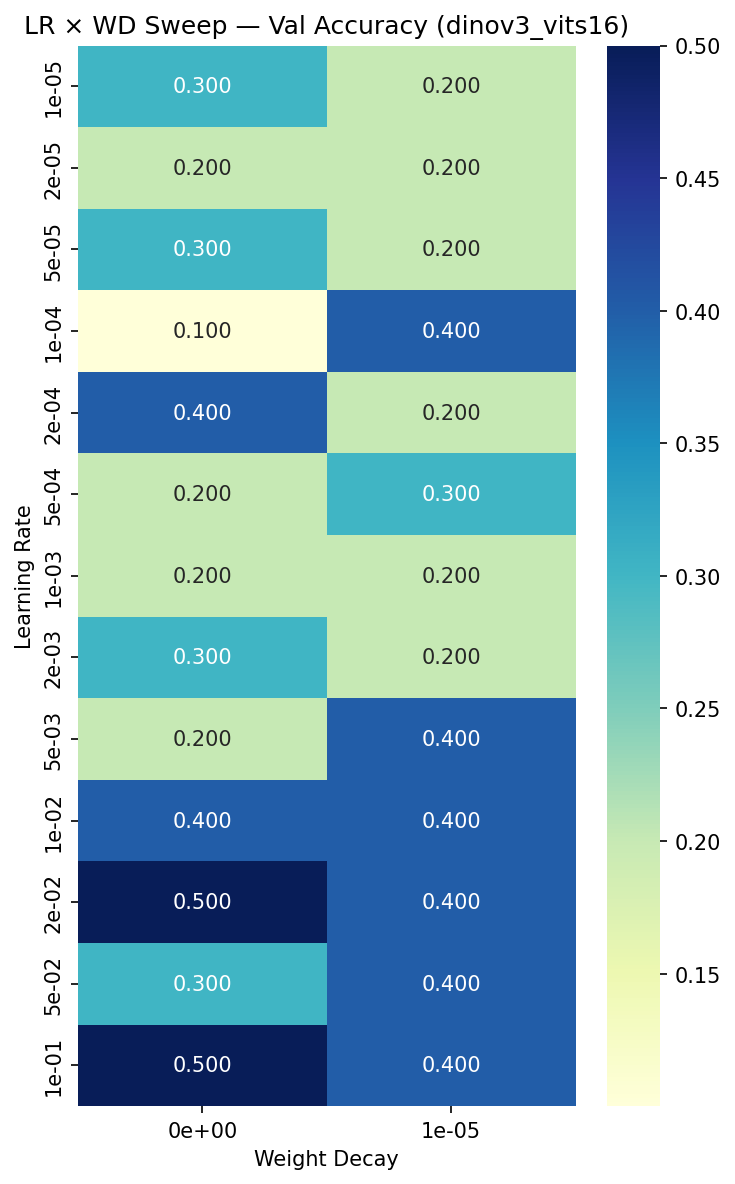

In [11]:
# Build a 2D matrix: rows = LR, cols = WD
lr_vals = sorted(set(r["lr"] for r in sweep_results))
wd_vals = sorted(set(r["wd"] for r in sweep_results))
acc_matrix = np.zeros((len(lr_vals), len(wd_vals)))

for r in sweep_results:
    i = lr_vals.index(r["lr"])
    j = wd_vals.index(r["wd"])
    acc_matrix[i, j] = r["val_acc"]

fig, ax = plt.subplots(figsize=(5, 8), dpi=150)
sns.heatmap(
    acc_matrix,
    annot=True, fmt=".3f",
    xticklabels=[f"{wd:.0e}" for wd in wd_vals],
    yticklabels=[f"{lr:.0e}" for lr in lr_vals],
    cmap="YlGnBu",
    ax=ax,
)
ax.set_xlabel("Weight Decay")
ax.set_ylabel("Learning Rate")
ax.set_title(f"LR × WD Sweep — Val Accuracy ({MODEL_NAME})")
plt.tight_layout()
plt.show()

## 9. Test Set Evaluation

In [12]:
test_metrics = evaluate_linear_classification(
    final_model, test_features, test_labels, device=DEVICE,
)

print(f"Test Top-1 Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Test Macro F1:       {test_metrics['macro_f1']:.4f}")
print("\nPer-class accuracy:")
for cls, acc in test_metrics["per_class_accuracy"].items():
    print(f"  {cls:>4s}: {acc:.4f}")

Test Top-1 Accuracy: 0.2600
Test Macro F1:       0.1991

Per-class accuracy:
   NOR: 0.6000
   DCM: 0.3000
   HCM: 0.0000
  MINF: 0.4000
    RV: 0.0000


/Users/lbokeria/projects/health_gc/heartfm-evals/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lbokeria/projects/health_gc/heartfm-evals/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lbokeria/projects/health_gc/heartfm-evals/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

### ROC AUC Scores

In [13]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(test_labels.numpy(), classes=list(range(NUM_PATHOLOGIES)))
y_prob = test_metrics["probabilities"]

macro_auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
per_class_auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average=None)

print(f"Macro ROC AUC (one-vs-rest): {macro_auc:.4f}\n")
print("Per-class ROC AUC:")
for cls_name, auc_val in zip(PATHOLOGY_CLASSES.keys(), per_class_auc):
    print(f"  {cls_name:>4s}: {auc_val:.4f}")

Macro ROC AUC (one-vs-rest): 0.6225

Per-class ROC AUC:
   NOR: 0.6300
   DCM: 0.5375
   HCM: 0.6225
  MINF: 0.5675
    RV: 0.7550


### Per-Class ROC Curves

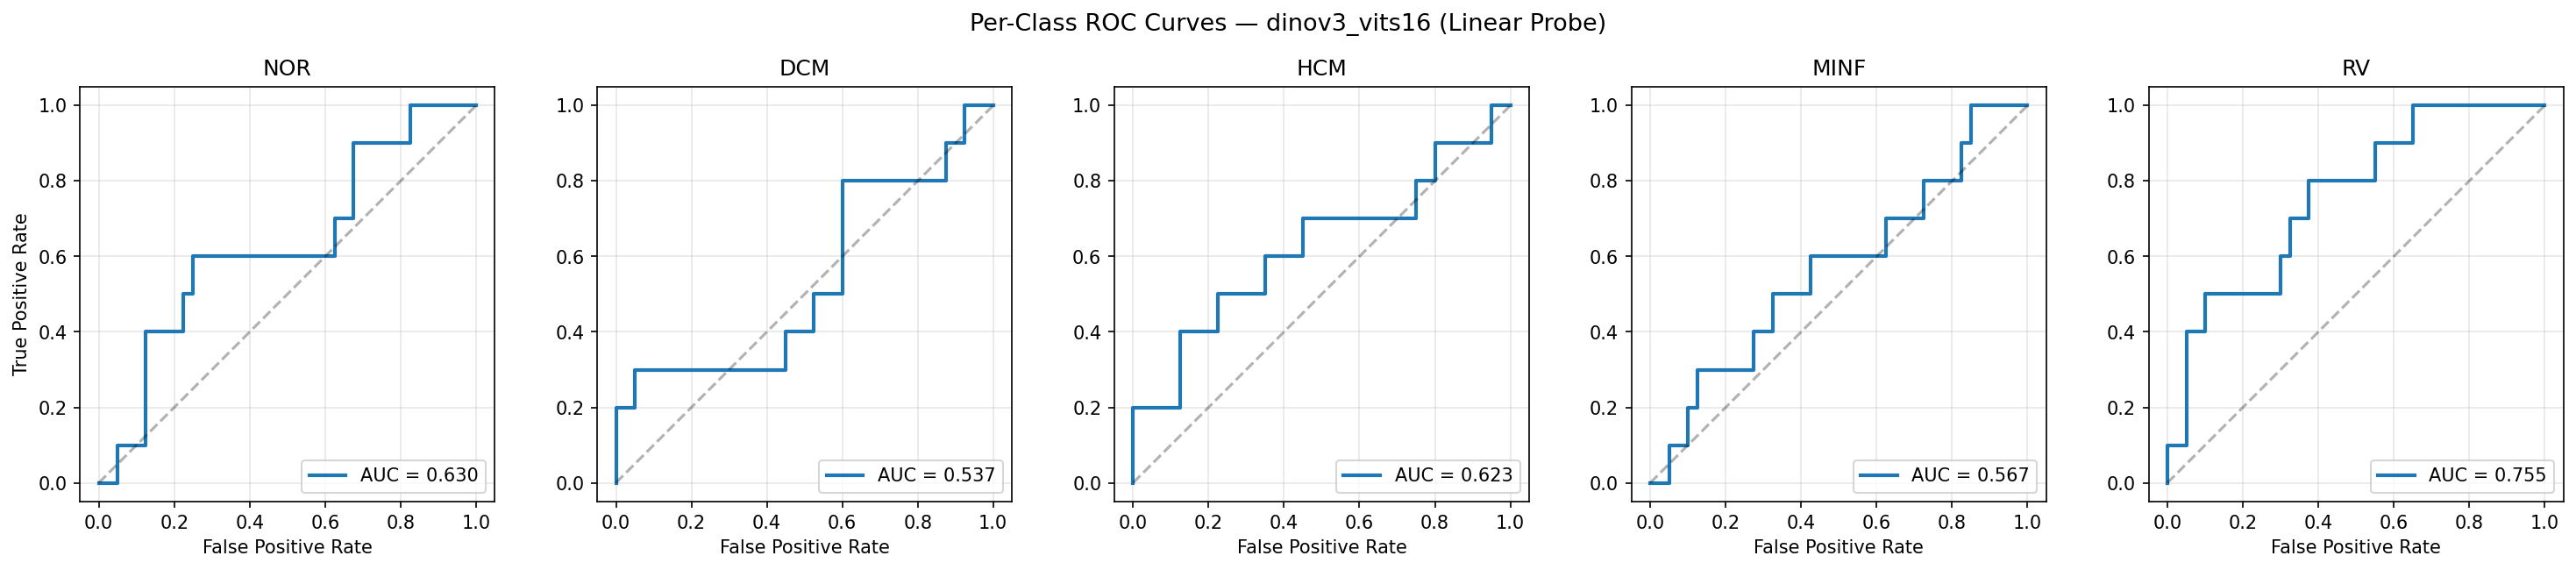

In [14]:
from sklearn.metrics import auc, roc_curve

fig, axes = plt.subplots(1, NUM_PATHOLOGIES, figsize=(4 * NUM_PATHOLOGIES, 4), dpi=150)

for i, (cls_name, cls_idx) in enumerate(PATHOLOGY_CLASSES.items()):
    fpr, tpr, _ = roc_curve(y_true_bin[:, cls_idx], y_prob[:, cls_idx])
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
    axes[i].plot([0, 1], [0, 1], "k--", alpha=0.3)
    axes[i].set_xlabel("False Positive Rate")
    if i == 0:
        axes[i].set_ylabel("True Positive Rate")
    axes[i].set_title(cls_name)
    axes[i].legend(loc="lower right")
    axes[i].set_aspect("equal")
    axes[i].grid(True, alpha=0.3)

fig.suptitle(f"Per-Class ROC Curves — {MODEL_NAME} (Linear Probe)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### ROC AUC Bar Plot

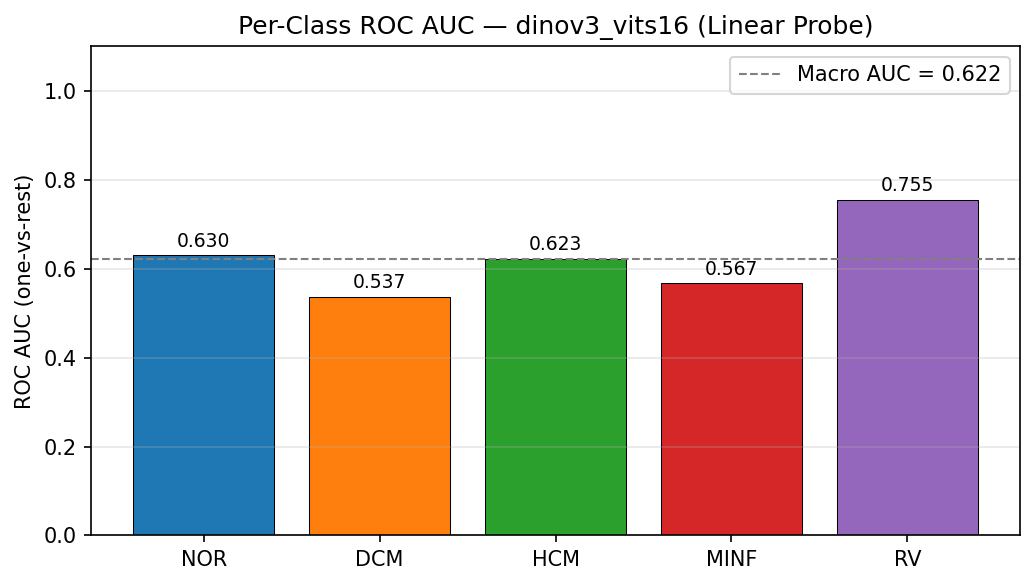

In [15]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

class_names = list(PATHOLOGY_CLASSES.keys())
colors = plt.cm.tab10(np.arange(NUM_PATHOLOGIES))

bars = ax.bar(class_names, per_class_auc, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(macro_auc, color="gray", linestyle="--", linewidth=1, label=f"Macro AUC = {macro_auc:.3f}")

for bar, val in zip(bars, per_class_auc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("ROC AUC (one-vs-rest)")
ax.set_title(f"Per-Class ROC AUC — {MODEL_NAME} (Linear Probe)")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Confusion Matrix

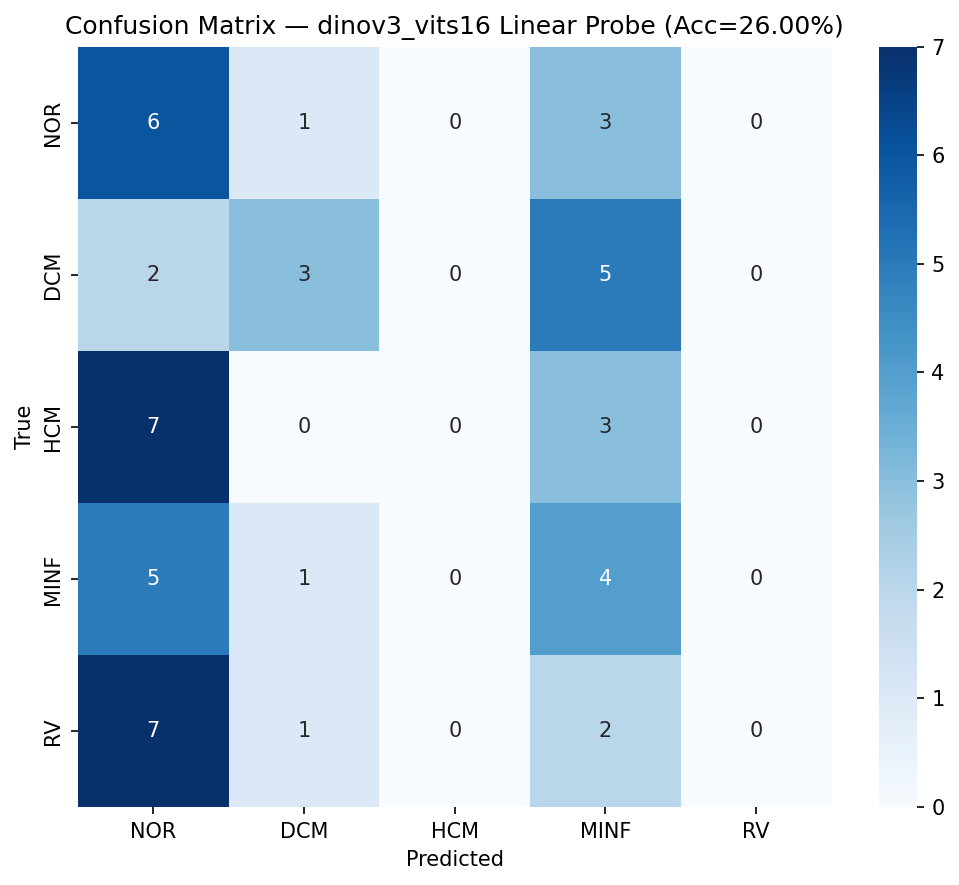

In [16]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)

class_names = list(PATHOLOGY_CLASSES.keys())
cm = test_metrics["confusion_matrix"]

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {MODEL_NAME} Linear Probe (Acc={test_metrics['accuracy']:.2%})")
plt.tight_layout()
plt.show()

### Classification Report

In [17]:
report_df = pd.DataFrame(test_metrics["classification_report"]).T
display(report_df.round(3))

,precision,recall,f1-score,support
NOR,0.222,0.60,0.324,10.00
DCM,0.500,0.30,0.375,10.00
HCM,0.000,0.00,0.000,10.00
MINF,0.235,0.40,0.296,10.00
RV,0.000,0.00,0.000,10.00
accuracy,0.260,0.26,0.260,0.26
macro avg,0.192,0.26,0.199,50.00
weighted avg,0.192,0.26,0.199,50.00


## 10. Per-Patient Results

In [18]:
results_df = pd.DataFrame({
    "pid": test_pids,
    "true_label": [PATHOLOGY_NAMES[l.item()] for l in test_labels],
    "predicted": [PATHOLOGY_NAMES[p] for p in test_metrics["predictions"]],
})
results_df["correct"] = results_df["true_label"] == results_df["predicted"]

print(f"Correct: {results_df['correct'].sum()} / {len(results_df)}")
print("\nMisclassified patients:")
display(results_df[~results_df["correct"]])

Correct: 13 / 50

Misclassified patients:


,pid,true_label,predicted,correct
0,patient101,DCM,NOR,False
3,patient104,HCM,NOR,False
4,patient105,HCM,NOR,False
5,patient106,DCM,MINF,False
7,patient108,HCM,NOR,False
8,patient109,RV,NOR,False
10,patient111,HCM,NOR,False
11,patient112,MINF,NOR,False
12,patient113,DCM,MINF,False
13,patient114,HCM,MINF,False


## 11. Comparison with Logistic Regression

Side-by-side comparison if the logistic regression notebook results are available.

In [19]:
# ── Fill in logistic regression results from acdc_classification.ipynb ──
# (Update these values after running the logistic regression notebook)
LOGREG_ACCURACY = None    # e.g. 0.58
LOGREG_MACRO_F1 = None    # e.g. 0.55
LOGREG_MACRO_AUC = None   # e.g. 0.85

if LOGREG_ACCURACY is not None:
    comparison = pd.DataFrame({
        "Metric": ["Test Accuracy", "Macro F1", "Macro ROC AUC"],
        "Logistic Regression": [LOGREG_ACCURACY, LOGREG_MACRO_F1, LOGREG_MACRO_AUC],
        "Linear Probe (SGD)": [
            test_metrics["accuracy"],
            test_metrics["macro_f1"],
            macro_auc,
        ],
    })
    comparison["Δ"] = comparison["Linear Probe (SGD)"] - comparison["Logistic Regression"]
    display(comparison.round(4))
else:
    print("Logistic regression results not set. Run acdc_classification.ipynb")
    print("and fill in LOGREG_ACCURACY / LOGREG_MACRO_F1 / LOGREG_MACRO_AUC above.")

Logistic regression results not set. Run acdc_classification.ipynb
and fill in LOGREG_ACCURACY / LOGREG_MACRO_F1 / LOGREG_MACRO_AUC above.


## 12. Summary

In [ ]:
print("=" * 65)
print("ACDC Pathology Classification — Linear Probe (SGD)")
print("=" * 65)
print(f"Backbone:          {MODEL_NAME} (embed_dim={EMBED_DIM})")
print(f"Feature type:      CLS×{N_LAST_BLOCKS} blocks + avgpool={USE_AVGPOOL}")
print(f"Feature dim:       {FEATURE_DIM} per slice → {PATIENT_DIM} per patient")
print(f"Classifier:        nn.Linear + SGD (momentum=0.9) + CosineAnnealing")
print(f"Best LR:           {best_lr:.4g}")
print(f"Best WD:           {best_wd:.4g}")
print(f"Epochs:            {EPOCHS}")
print(f"Train patients:    {len(train_pids)}")
print(f"Val patients:      {len(val_pids_list)}")
print(f"Test patients:     {len(test_pids)}")
print("─" * 65)
print(f"Test Accuracy:     {test_metrics['accuracy']:.4f}")
print(f"Test Macro F1:     {test_metrics['macro_f1']:.4f}")
print(f"Test Macro AUC:    {macro_auc:.4f}")
print("=" * 65)